In [7]:
# Core libraries
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch utilities
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from torchvision.datasets.vision import VisionDataset
from torchvision.ops import box_iou


In [11]:
import os
import torch
from PIL import Image
from torchvision.datasets import VisionDataset

class IDDDataset(VisionDataset):
    def __init__(self, root, split="train", transforms=None):
        super().__init__(root)
        self.root = root
        self.transforms = transforms

        self.img_dir = os.path.join(root, "images", split)
        self.label_dir = os.path.join(root, "labels", split)

        all_images = sorted([
            f for f in os.listdir(self.img_dir)
            if f.endswith((".jpg", ".png"))
        ])

        # ALWAYS define self.images
        self.images = []

        for img_name in all_images:
            label_path = os.path.join(
                self.label_dir,
                img_name.replace(".jpg", ".txt").replace(".png", ".txt")
            )

            if not os.path.exists(label_path):
                continue

            # keep image if it has at least ONE valid box
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    _, _, _, w, h = map(float, parts)
                    if w > 0 and h > 0:
                        self.images.append(img_name)
                        break

        print(f"[{split}] Images with valid annotations: {len(self.images)}")

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(
            self.label_dir,
            img_name.replace(".jpg", ".txt").replace(".png", ".txt")
        )

        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        boxes = []
        labels = []

        with open(label_path, "r") as f:
            for line in f:
                cls_id, xc, yc, w, h = map(float, line.strip().split())

                xmin = (xc - w / 2) * width
                ymin = (yc - h / 2) * height
                xmax = (xc + w / 2) * width
                ymax = (yc + h / 2) * height

                if xmax <= xmin or ymax <= ymin:
                    continue

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(int(cls_id) + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.images)


In [ ]:
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader

# -----------------------------
# TRANSFORMS
# -----------------------------
import torchvision.transforms as T

def get_transform():
    return T.Compose([
        T.Resize((800, 1333)),   # Faster R-CNN standard
        T.ToTensor()
    ])


# -----------------------------
# LOAD IDD DATASETS (PRE-SPLIT)
# -----------------------------
train_dataset = IDDDataset(
    root="/workspace/datasets/IDD_YOLO",
    split="train",
    transforms=get_transform()
)

val_dataset = IDDDataset(
    root="/workspace/datasets/IDD_YOLO",
    split="val",
    transforms=get_transform()
)

# -----------------------------
# DATALOADERS
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=4,
    collate_fn=lambda x: tuple(zip(*x))
)


[train] Images with valid annotations: 31255
[val] Images with valid annotations: 10199


In [10]:
# IDD classes (with background at index 0)
idd_classes = [
    "__background__",   # index 0 (required by Faster R-CNN)
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle",
    "autorickshaw",
    "animal",
    "traffic light",
    "traffic sign"
]

num_classes = len(idd_classes)  # => 12


In [11]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load Faster R-CNN pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace the classifier head for our custom number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [13]:
print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

print("Train loader batches:", len(train_loader))
print("Val loader batches:", len(val_loader))


Train dataset size: 31255
Val dataset size: 10199
Train loader batches: 7814
Val loader batches: 5100


In [22]:
import torch
import torchvision
from torch.utils.data import DataLoader
import time
import os

#  Enable faster conv backend benchmarking
torch.backends.cudnn.benchmark = True

#  Optional: Use PyTorch 2.x compile for speedup (comment out if not using PyTorch 2.x)
# model = torch.compile(model)

#  Use AMP (mixed precision) support
from torch.cuda.amp import GradScaler

scaler = GradScaler()

#  Set training parameters optimized for your system
num_epochs = 1
train_batch_size = 30       # Can go higher if VRAM allows
val_batch_size = 30
learning_rate = 0.005
momentum = 0.9
weight_decay = 0.0005
save_path = "fasterrcnn_kitti.pth"

#  Use max CPU cores for loading, but keep a few for other ops
num_workers = 3

#  Use pin_memory for faster host-to-device transfers
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers // 2,
    pin_memory=True
)

#  Optimizer: SGD with momentum and weight decay
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

#  LR Scheduler: Reduce LR after 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/tmp/ipykernel_141578/2359743923.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [17]:
from torch.cuda.amp import autocast
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Training on device: {device}")
print("Starting training...\n")

log_interval = 50   # print every 50 batches

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()

    print(f"\n========== Epoch {epoch+1}/{num_epochs} ==========")

    for step, (images, targets) in enumerate(train_loader):
        # ---- LOG FIRST BATCH ----
        if step == 0:
            print("First batch loaded, running forward pass...")

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        # ---- FORWARD + LOSS ----
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # ---- BACKWARD ----
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = losses.item()
        epoch_loss += batch_loss

        # ---- PERIODIC LOGGING ----
        if step % log_interval == 0:
            mem = torch.cuda.memory_allocated() / 1024**2 if device.type == "cuda" else 0
            print(
                f"Epoch {epoch+1} | "
                f"Step {step}/{len(train_loader)} | "
                f"Loss {batch_loss:.4f} | "
                f"GPU Mem {mem:.1f} MB"
            )

    # ---- LR SCHEDULER ----
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    duration = time.time() - start_time

    print(
        f"\nEpoch {epoch+1} completed | "
        f"Avg Loss: {avg_loss:.4f} | "
        f"Time: {duration/60:.2f} min"
    )

    # ---- SAVE CHECKPOINT ----
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
        },
        f"fasterrcnn_epoch{epoch+1}.pth"
    )

# ---- FINAL SAVE ----
torch.save(model.state_dict(), save_path)
print("\nTraining complete and model saved.")


Training on device: cuda
Starting training...


========== Epoch 1/1 ==========
First batch loaded, running forward pass...


/tmp/ipykernel_141578/3871370378.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Step 0/1042 | Loss 3.2909 | GPU Mem 3198.4 MB
Epoch 1 | Step 50/1042 | Loss 4.5717 | GPU Mem 3198.3 MB
Epoch 1 | Step 100/1042 | Loss 7.1811 | GPU Mem 1069.9 MB
Epoch 1 | Step 150/1042 | Loss 8.6000 | GPU Mem 1069.9 MB
Epoch 1 | Step 200/1042 | Loss 6.2752 | GPU Mem 1069.9 MB
Epoch 1 | Step 250/1042 | Loss 5.8574 | GPU Mem 1069.9 MB
Epoch 1 | Step 300/1042 | Loss 5.5506 | GPU Mem 1069.9 MB
Epoch 1 | Step 350/1042 | Loss 4.9007 | GPU Mem 1069.9 MB
Epoch 1 | Step 400/1042 | Loss 6.3375 | GPU Mem 1069.9 MB
Epoch 1 | Step 450/1042 | Loss 5.7195 | GPU Mem 1069.9 MB
Epoch 1 | Step 500/1042 | Loss 7.5946 | GPU Mem 1069.9 MB
Epoch 1 | Step 550/1042 | Loss 4.0552 | GPU Mem 1069.9 MB
Epoch 1 | Step 600/1042 | Loss 3.6253 | GPU Mem 1069.9 MB
Epoch 1 | Step 650/1042 | Loss 6.1572 | GPU Mem 1069.9 MB
Epoch 1 | Step 700/1042 | Loss 5.4325 | GPU Mem 1069.9 MB
Epoch 1 | Step 750/1042 | Loss 6.6711 | GPU Mem 1069.9 MB
Epoch 1 | Step 800/1042 | Loss 6.6809 | GPU Mem 1069.9 MB
Epoch 1 | Step 85

In [7]:
import torch
import torchvision
from torch.utils.data import DataLoader
import time
import os

#  Enable faster conv backend benchmarking
torch.backends.cudnn.benchmark = True

#  Optional: Use PyTorch 2.x compile for speedup (comment out if not using PyTorch 2.x)
# model = torch.compile(model)

#  Use AMP (mixed precision) support
from torch.cuda.amp import GradScaler

scaler = GradScaler()

#  Set training parameters optimized for your system
num_epochs = 1
train_batch_size = 4       # Can go higher if VRAM allows
val_batch_size = 4
learning_rate = 0.005
momentum = 0.9
weight_decay = 0.0005
save_path = "fasterrcnn_kitti.pth"

#  Use max CPU cores for loading, but keep a few for other ops
num_workers = 3

#  Use pin_memory for faster host-to-device transfers
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers // 2,
    pin_memory=True
)

#  Optimizer: SGD with momentum and weight decay
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

#  LR Scheduler: Reduce LR after 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/tmp/ipykernel_142804/3220544492.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [8]:
from torch.cuda.amp import autocast
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Training on device: {device}")
print("Starting training...\n")

log_interval = 10   # print every 50 batches

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()

    print(f"\n========== Epoch {epoch+1}/{num_epochs} ==========")

    for step, (images, targets) in enumerate(train_loader):
        # ---- LOG FIRST BATCH ----
        if step == 0:
            print("First batch loaded, running forward pass...")

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        # ---- FORWARD + LOSS ----
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # ---- BACKWARD ----
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_loss = losses.item()
        epoch_loss += batch_loss

        # ---- PERIODIC LOGGING ----
        if step % log_interval == 0:
            mem = torch.cuda.memory_allocated() / 1024**2 if device.type == "cuda" else 0
            print(
                f"Epoch {epoch+1} | "
                f"Step {step}/{len(train_loader)} | "
                f"Loss {batch_loss:.4f} | "
                f"GPU Mem {mem:.1f} MB"
            )

    # ---- LR SCHEDULER ----
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    duration = time.time() - start_time

    print(
        f"\nEpoch {epoch+1} completed | "
        f"Avg Loss: {avg_loss:.4f} | "
        f"Time: {duration/60:.2f} min"
    )

    # ---- SAVE CHECKPOINT ----
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
        },
        f"fasterrcnn_epoch{epoch+1}.pth"
    )

# ---- FINAL SAVE ----
torch.save(model.state_dict(), save_path)
print("\nTraining complete and model saved.")


Training on device: cuda
Starting training...


========== Epoch 1/1 ==========
First batch loaded, running forward pass...


/tmp/ipykernel_142804/318350814.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Step 0/7814 | Loss 16.2734 | GPU Mem 437.2 MB
Epoch 1 | Step 10/7814 | Loss 7.9029 | GPU Mem 597.0 MB
Epoch 1 | Step 20/7814 | Loss 10.6034 | GPU Mem 597.3 MB
Epoch 1 | Step 30/7814 | Loss 4.2275 | GPU Mem 597.3 MB
Epoch 1 | Step 40/7814 | Loss 0.7446 | GPU Mem 597.3 MB
Epoch 1 | Step 50/7814 | Loss 8.2603 | GPU Mem 597.0 MB
Epoch 1 | Step 60/7814 | Loss 1.7076 | GPU Mem 597.3 MB
Epoch 1 | Step 70/7814 | Loss 4.8005 | GPU Mem 597.3 MB
Epoch 1 | Step 80/7814 | Loss 25.1986 | GPU Mem 597.3 MB
Epoch 1 | Step 90/7814 | Loss 2.7373 | GPU Mem 597.3 MB
Epoch 1 | Step 100/7814 | Loss 5.6758 | GPU Mem 597.0 MB
Epoch 1 | Step 110/7814 | Loss 12.1895 | GPU Mem 597.0 MB
Epoch 1 | Step 120/7814 | Loss 9.6985 | GPU Mem 597.3 MB
Epoch 1 | Step 130/7814 | Loss 3.8147 | GPU Mem 597.3 MB
Epoch 1 | Step 140/7814 | Loss 9.0121 | GPU Mem 597.3 MB
Epoch 1 | Step 150/7814 | Loss 10.0447 | GPU Mem 597.3 MB
Epoch 1 | Step 160/7814 | Loss 14.3132 | GPU Mem 597.3 MB
Epoch 1 | Step 170/7814 | Loss 15.60

KeyboardInterrupt: 

In [7]:
import torch
import torchvision
from torch.utils.data import DataLoader
import time
import os

#  Enable faster conv backend benchmarking
torch.backends.cudnn.benchmark = True

#  Optional: Use PyTorch 2.x compile for speedup (comment out if not using PyTorch 2.x)
# model = torch.compile(model)

#  Use AMP (mixed precision) support
from torch.cuda.amp import GradScaler

scaler = GradScaler()

#  Set training parameters optimized for your system
num_epochs = 20
train_batch_size = 30       # Can go higher if VRAM allows
val_batch_size = 30
learning_rate = 0.005
momentum = 0.9
weight_decay = 0.0005
save_path = "fasterrcnn_kitti.pth"

#  Use max CPU cores for loading, but keep a few for other ops
num_workers = 1

#  Use pin_memory for faster host-to-device transfers
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers // 2,
    pin_memory=True
)

#  Optimizer: SGD with momentum and weight decay
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

#  LR Scheduler: Reduce LR after 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/tmp/ipykernel_200074/1838119016.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
from torch.cuda.amp import autocast
import torchvision
import torch
import time

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f" Training on: {device}")
print(" Starting training...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        #  Mixed precision context
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        #  Scale gradients and backpropagate
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

    #  Update LR
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    duration = time.time() - start_time
    print(f"[Epoch {epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f} | Time: {duration:.2f} sec")

    #  Save model after each epoch
    torch.save(model.state_dict(), f"fasterrcnn_epoch{epoch+1}.pth")

#  Final model save
torch.save(model.state_dict(), save_path)
print(" Training complete and model saved.")


 Training on: cuda
 Starting training...


/tmp/ipykernel_200074/2270272226.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1/20]  Loss: 5.8271 | Time: 877.35 sec


In [10]:
from torch.cuda.amp import autocast
import torchvision
import torch
import time

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f" Training on: {device}")
print(" Starting training...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        #  Mixed precision context
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        #  Scale gradients and backpropagate
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

    #  Update LR
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    duration = time.time() - start_time
    print(f"[Epoch {epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f} | Time: {duration:.2f} sec")

    #  Save model after each epoch
    torch.save(model.state_dict(), f"fasterrcnn_epoch{epoch+1}.pth")

#  Final model save
torch.save(model.state_dict(), save_path)
print(" Training complete and model saved.")


 Training on: cuda
 Starting training...


/tmp/ipykernel_142804/2270272226.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1/40]  Loss: 7.3803 | Time: 885.66 sec
[Epoch 2/40]  Loss: 7.3513 | Time: 881.01 sec
[Epoch 3/40]  Loss: 6.9910 | Time: 881.97 sec
[Epoch 4/40]  Loss: 7.0294 | Time: 883.04 sec
[Epoch 5/40]  Loss: nan | Time: 785.32 sec
[Epoch 6/40]  Loss: nan | Time: 763.11 sec
[Epoch 7/40]  Loss: nan | Time: 759.19 sec
[Epoch 8/40]  Loss: nan | Time: 760.35 sec
[Epoch 9/40]  Loss: nan | Time: 762.64 sec
[Epoch 10/40]  Loss: nan | Time: 762.24 sec
[Epoch 11/40]  Loss: nan | Time: 763.26 sec
[Epoch 12/40]  Loss: nan | Time: 762.56 sec
[Epoch 13/40]  Loss: nan | Time: 760.45 sec
[Epoch 14/40]  Loss: nan | Time: 762.70 sec
[Epoch 15/40]  Loss: nan | Time: 761.42 sec
[Epoch 16/40]  Loss: nan | Time: 761.51 sec
[Epoch 17/40]  Loss: nan | Time: 760.36 sec
[Epoch 18/40]  Loss: nan | Time: 762.14 sec
[Epoch 19/40]  Loss: nan | Time: 761.89 sec
[Epoch 20/40]  Loss: nan | Time: 761.37 sec
[Epoch 21/40]  Loss: nan | Time: 762.85 sec
[Epoch 22/40]  Loss: nan | Time: 761.53 sec
[Epoch 23/40]  Loss: nan | Ti

In [13]:
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

# Switch to eval mode
model.eval()

# Store predictions and targets
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = list(img.to(device) for img in images)
        outputs = model(images)
        
        for i in range(len(outputs)):
            preds = outputs[i]
            gts = targets[i]
            
            all_preds.append({
                'boxes': preds['boxes'].cpu(),
                'labels': preds['labels'].cpu(),
                'scores': preds['scores'].cpu()
            })
            all_targets.append({
                'boxes': gts['boxes'].cpu(),
                'labels': gts['labels'].cpu()
            })



00%|██████████| 5100/5100 [10:40<00:00,  7.97it/s]

In [17]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import numpy as np

def compute_iou(box1, box2):
    """Compute IoU between two boxes"""
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    box1Area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2Area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return interArea / float(box1Area + box2Area - interArea)


In [18]:
from collections import defaultdict

IOU_THRESHOLD = 0.5
class_stats = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0, 'conf': [], 'gt_count': 0})

for pred, target in zip(all_preds, all_targets):
    pred_boxes = pred['boxes']
    pred_labels = pred['labels']
    pred_scores = pred['scores']
    
    gt_boxes = target['boxes']
    gt_labels = target['labels']
    
    matched_gt = set()
    
    for i, p_box in enumerate(pred_boxes):
        iou_max = 0
        match_idx = -1
        for j, g_box in enumerate(gt_boxes):
            iou = compute_iou(p_box.numpy(), g_box.numpy())
            if iou > iou_max:
                iou_max = iou
                match_idx = j

        pred_cls = int(pred_labels[i])
        
        if iou_max >= IOU_THRESHOLD and match_idx not in matched_gt and pred_cls == int(gt_labels[match_idx]):
            class_stats[pred_cls]['TP'] += 1
            class_stats[pred_cls]['conf'].append(float(pred_scores[i]))
            matched_gt.add(match_idx)
        else:
            class_stats[pred_cls]['FP'] += 1
            class_stats[pred_cls]['conf'].append(float(pred_scores[i]))
    
    for j, gt_cls in enumerate(gt_labels):
        if j not in matched_gt:
            class_stats[int(gt_cls)]['FN'] += 1
            class_stats[int(gt_cls)]['gt_count'] += 1


In [19]:
per_class_metrics = {}

for cls, stats in class_stats.items():
    TP = stats['TP']
    FP = stats['FP']
    FN = stats['FN']
    total = TP + FP + FN
    
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    fnr = FN / (TP + FN + 1e-6)
    fpr = FP / (FP + TP + 1e-6)

    per_class_metrics[cls] = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'FNR': fnr,
        'FPR': fpr,
        'TP': TP, 'FP': FP, 'FN': FN
    }

# Display the metrics
import pandas as pd
pd.DataFrame(per_class_metrics).T


,Precision,Recall,F1,FNR,FPR,TP,FP,FN
1,0.000194,0.003485,0.000367,0.996515,0.999806,63.0,324644.0,18015.0
7,0.000003,0.003515,0.000007,0.996485,0.999997,2.0,573025.0,567.0
4,0.004207,0.013846,0.006453,0.986154,0.995793,98.0,23194.0,6980.0
2,0.000062,0.000163,0.000090,0.999837,0.999938,4.0,64466.0,24514.0
8,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,16758.0,7782.0
5,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,184.0,4916.0
3,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,1523.0,24843.0
11,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,5762.0,4287.0
10,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,5041.0,919.0
6,0.000000,0.000000,0.000000,1.000000,0.999999,0.0,1.0,25489.0


In [20]:
def calculate_map_iou_thresholds(preds, targets, iou_thresholds=np.arange(0.5, 1.0, 0.05)):
    aps = []

    for iou_thresh in iou_thresholds:
        cls_ap = []
        for cls in class_stats.keys():
            TP, FP, FN = 0, 0, 0
            for pred, target in zip(preds, targets):
                pred_boxes = pred['boxes']
                pred_labels = pred['labels']
                pred_scores = pred['scores']
                
                gt_boxes = target['boxes']
                gt_labels = target['labels']

                matched_gt = set()

                for i, p_box in enumerate(pred_boxes):
                    if int(pred_labels[i]) != cls:
                        continue
                    best_iou = 0
                    match_idx = -1
                    for j, g_box in enumerate(gt_boxes):
                        if int(gt_labels[j]) != cls:
                            continue
                        iou = compute_iou(p_box.numpy(), g_box.numpy())
                        if iou > best_iou:
                            best_iou = iou
                            match_idx = j

                    if best_iou >= iou_thresh and match_idx not in matched_gt:
                        TP += 1
                        matched_gt.add(match_idx)
                    else:
                        FP += 1

                FN += sum(1 for g in gt_labels if int(g) == cls) - len(matched_gt)
            
            precision = TP / (TP + FP + 1e-6)
            recall = TP / (TP + FN + 1e-6)
            ap = 2 * precision * recall / (precision + recall + 1e-6)
            cls_ap.append(ap)
        
        aps.append(np.mean(cls_ap))

    return aps


In [21]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)
map_list = calculate_map_iou_thresholds(all_preds, all_targets, iou_thresholds)

for iou, ap in zip(iou_thresholds, map_list):
    print(f"mAP@{iou:.2f}: {ap:.4f}")

print(f"\n Final mAP@0.5: {map_list[0]:.4f}")
print(f" Final mAP@0.5:0.95 (COCO style): {np.mean(map_list):.4f}")


mAP@0.50: 0.0007
mAP@0.55: 0.0004
mAP@0.60: 0.0002
mAP@0.65: 0.0001
mAP@0.70: 0.0001
mAP@0.75: 0.0000
mAP@0.80: 0.0000
mAP@0.85: 0.0000
mAP@0.90: 0.0000
mAP@0.95: 0.0000

 Final mAP@0.5: 0.0007
 Final mAP@0.5:0.95 (COCO style): 0.0001


In [24]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load trained model
checkpoint = torch.load("fasterrcnn_kitti.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint)
model.to(device)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i in range(len(outputs)):
            all_preds.append({
                "boxes": outputs[i]["boxes"].cpu(),
                "labels": outputs[i]["labels"].cpu(),
                "scores": outputs[i]["scores"].cpu()
            })
            all_targets.append({
                "boxes": targets[i]["boxes"].cpu(),
                "labels": targets[i]["labels"].cpu()
            })

print("Inference complete")


/tmp/ipykernel_296718/3683091838.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("fasterrcnn_kitti.pth", map_location=device)
100%|██████████| 51

Inference complete


In [22]:
pwd

'/workspace'

In [25]:
import numpy as np

def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter / (area1 + area2 - inter)


In [26]:
from collections import defaultdict

score_thresh = 0.5
iou_thresh = 0.5

class_stats = defaultdict(lambda: {"TP":0, "FP":0, "FN":0})

for pred, gt in zip(all_preds, all_targets):

    pb, pl, ps = pred["boxes"], pred["labels"], pred["scores"]
    gb, gl = gt["boxes"], gt["labels"]

    keep = ps >= score_thresh
    pb, pl, ps = pb[keep], pl[keep], ps[keep]

    order = torch.argsort(ps, descending=True)
    pb, pl = pb[order], pl[order]

    for cls in torch.unique(torch.cat([pl, gl])):

        cls = int(cls)
        matched_gt = set()

        p_idx = (pl == cls).nonzero(as_tuple=True)[0]
        g_idx = (gl == cls).nonzero(as_tuple=True)[0]

        for i in p_idx:
            best_iou, best_j = 0, -1
            for j in g_idx:
                if j.item() in matched_gt:
                    continue
                iou = compute_iou(pb[i].numpy(), gb[j].numpy())
                if iou > best_iou:
                    best_iou, best_j = iou, j.item()

            if best_iou >= iou_thresh:
                class_stats[cls]["TP"] += 1
                matched_gt.add(best_j)
            else:
                class_stats[cls]["FP"] += 1

        class_stats[cls]["FN"] += max(0, len(g_idx) - len(matched_gt))


In [27]:
import pandas as pd

rows = []

for cls, s in class_stats.items():
    TP, FP, FN = s["TP"], s["FP"], s["FN"]

    P = TP / (TP + FP + 1e-6)
    R = TP / (TP + FN + 1e-6)
    F1 = 2 * P * R / (P + R + 1e-6)
    FNR = FN / (TP + FN + 1e-6)
    FPR = FP / (TP + FP + 1e-6)

    rows.append({
        "Class": cls,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "Precision": round(P,4),
        "Recall": round(R,4),
        "F1": round(F1,4),
        "FNR": round(FNR,4),
        "FPR": round(FPR,4)
    })

df_metrics = pd.DataFrame(rows).sort_values("Class")
df_metrics


,Class,TP,FP,FN,Precision,Recall,F1,FNR,FPR
2,1,349,840,17729,0.2935,0.0193,0.0362,0.9807,0.7065
3,2,615,1056,23903,0.3680,0.0251,0.0470,0.9749,0.6320
1,3,1441,2485,23402,0.3670,0.0580,0.1002,0.9420,0.6330
0,4,406,452,6672,0.4732,0.0574,0.1023,0.9426,0.5268
6,5,504,423,4412,0.5437,0.1025,0.1725,0.8975,0.4563
4,6,1009,1264,24480,0.4439,0.0396,0.0727,0.9604,0.5561
9,7,0,0,569,0.0000,0.0000,0.0000,1.0000,0.0000
7,8,95,74,7687,0.5621,0.0122,0.0239,0.9878,0.4379
8,9,0,0,1460,0.0000,0.0000,0.0000,1.0000,0.0000
10,10,0,0,919,0.0000,0.0000,0.0000,1.0000,0.0000


In [28]:
def compute_map(preds, targets, iou_thresholds=np.arange(0.5,1.0,0.05), score_thresh=0.5):
    aps = []

    for iou_t in iou_thresholds:
        cls_ap = []

        for cls in set(int(l) for t in targets for l in t["labels"]):
            TP = FP = FN = 0

            for pred, gt in zip(preds, targets):

                pb, pl, ps = pred["boxes"], pred["labels"], pred["scores"]
                gb, gl = gt["boxes"], gt["labels"]

                keep = ps >= score_thresh
                pb, pl, ps = pb[keep], pl[keep], ps[keep]

                order = torch.argsort(ps, descending=True)
                pb, pl = pb[order], pl[order]

                p_idx = (pl == cls).nonzero(as_tuple=True)[0]
                g_idx = (gl == cls).nonzero(as_tuple=True)[0]

                matched = set()

                for i in p_idx:
                    best_iou, best_j = 0, -1
                    for j in g_idx:
                        if j.item() in matched:
                            continue
                        iou = compute_iou(pb[i].numpy(), gb[j].numpy())
                        if iou > best_iou:
                            best_iou, best_j = iou, j.item()

                    if best_iou >= iou_t:
                        TP += 1
                        matched.add(best_j)
                    else:
                        FP += 1

                FN += max(0, len(g_idx) - len(matched))

            P = TP / (TP + FP + 1e-6)
            R = TP / (TP + FN + 1e-6)
            cls_ap.append(P)

        aps.append(np.mean(cls_ap))

    return aps


In [29]:
iou_thresholds = np.arange(0.5,1.0,0.05)
map_vals = compute_map(all_preds, all_targets, iou_thresholds)

for iou, ap in zip(iou_thresholds, map_vals):
    print(f"mAP@{iou:.2f}: {ap:.4f}")

print("\nFinal mAP@0.5:", round(map_vals[0],4))
print("Final mAP@0.5:0.95:", round(np.mean(map_vals),4))


mAP@0.50: 0.2774
mAP@0.55: 0.2513
mAP@0.60: 0.2123
mAP@0.65: 0.1723
mAP@0.70: 0.1292
mAP@0.75: 0.0825
mAP@0.80: 0.0460
mAP@0.85: 0.0209
mAP@0.90: 0.0072
mAP@0.95: 0.0003

Final mAP@0.5: 0.2774
Final mAP@0.5:0.95: 0.1199


In [30]:
rows = []

for cls, s in class_stats.items():
    TP, FP, FN = s["TP"], s["FP"], s["FN"]

    P = TP / (TP + FP + 1e-6)
    R = TP / (TP + FN + 1e-6)
    F1 = 2 * P * R / (P + R + 1e-6)
    FNR = FN / (TP + FN + 1e-6)
    FPR = FP / (TP + FP + 1e-6)

    rows.append({
        "Class": cls,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "Precision": round(P,4),
        "Recall": round(R,4),
        "F1": round(F1,4),
        "FNR": round(FNR,4),
        "FPR": round(FPR,4)
    })

df_metrics = pd.DataFrame(rows)
df_metrics


,Class,TP,FP,FN,Precision,Recall,F1,FNR,FPR
0,4,406,452,6672,0.4732,0.0574,0.1023,0.9426,0.5268
1,3,1441,2485,23402,0.3670,0.0580,0.1002,0.9420,0.6330
2,1,349,840,17729,0.2935,0.0193,0.0362,0.9807,0.7065
3,2,615,1056,23903,0.3680,0.0251,0.0470,0.9749,0.6320
4,6,1009,1264,24480,0.4439,0.0396,0.0727,0.9604,0.5561
5,11,0,0,4287,0.0000,0.0000,0.0000,1.0000,0.0000
6,5,504,423,4412,0.5437,0.1025,0.1725,0.8975,0.4563
7,8,95,74,7687,0.5621,0.0122,0.0239,0.9878,0.4379
8,9,0,0,1460,0.0000,0.0000,0.0000,1.0000,0.0000
9,7,0,0,569,0.0000,0.0000,0.0000,1.0000,0.0000


In [31]:
def calculate_map(preds, targets, iou_thresholds=np.arange(0.5, 1.0, 0.05)):
    aps = []

    for iou_t in iou_thresholds:
        cls_ap = []

        for cls in class_stats.keys():
            TP = FP = FN = 0

            for pred, gt in zip(preds, targets):
                p_boxes = pred["boxes"]
                p_labels = pred["labels"]
                g_boxes = gt["boxes"]
                g_labels = gt["labels"]

                matched = set()

                for i in range(len(p_boxes)):
                    if int(p_labels[i]) != cls:
                        continue

                    best_iou = 0
                    best_j = -1
                    for j in range(len(g_boxes)):
                        if j in matched or int(g_labels[j]) != cls:
                            continue
                        iou = compute_iou(p_boxes[i].numpy(), g_boxes[j].numpy())
                        if iou > best_iou:
                            best_iou = iou
                            best_j = j

                    if best_iou >= iou_t:
                        TP += 1
                        matched.add(best_j)
                    else:
                        FP += 1

                FN += sum(int(l)==cls for l in g_labels) - len(matched)

            P = TP / (TP + FP + 1e-6)
            R = TP / (TP + FN + 1e-6)
            cls_ap.append(2 * P * R / (P + R + 1e-6))

        aps.append(np.mean(cls_ap))

    return aps

iou_vals = np.arange(0.5, 1.0, 0.05)
map_list = calculate_map(all_preds, all_targets, iou_vals)

print(f"Final mAP@0.5: {map_list[0]:.4f}")
print(f"Final mAP@0.5:0.95: {np.mean(map_list):.4f}")


Final mAP@0.5: 0.0350
Final mAP@0.5:0.95: 0.0124


In [32]:
df_metrics.to_csv("fasterrcnn_idd_final_metrics.csv", index=False)
print("Saved: fasterrcnn_idd_final_metrics.csv")


Saved: fasterrcnn_idd_final_metrics.csv


In [3]:
import torch
import torchvision


In [5]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

num_classes = 12  # background + 11 IDD classes
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load Faster R-CNN pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace the classifier head for our custom number of classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("fasterrcnn_kitti.pth", map_location=device)

model.to(device)
model.eval()


/tmp/ipykernel_302310/3600822859.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("fasterrcnn_kitti.pth", map_location=device)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [14]:
def __getitem__(self, idx):
    img_name = self.images[idx]

    img_path = os.path.join(self.img_dir, img_name)
    label_path = os.path.join(
        self.label_dir,
        img_name.replace(".jpg", ".txt").replace(".png", ".txt")
    )

    img = Image.open(img_path).convert("RGB")
    width, height = img.size

    boxes = []
    labels = []

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                cls_id, xc, yc, w, h = map(float, line.strip().split())

                xmin = (xc - w / 2) * width
                ymin = (yc - h / 2) * height
                xmax = (xc + w / 2) * width
                ymax = (yc + h / 2) * height

                if xmax > xmin and ymax > ymin:
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(cls_id) + 1)

    boxes = torch.tensor(boxes, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.int64)

    target = {
        "boxes": boxes,
        "labels": labels,
        "image_id": torch.tensor([idx]),
        "image_name": img_name
    }

    if self.transforms:
        img = self.transforms(img)

    return img, target


In [15]:
import torch
import json
from tqdm import tqdm

model.eval()

coco_predictions = []
image_id_map = {}  # map dataset index → COCO image_id

# Load COCO GT to get correct image_ids
with open("/workspace/datasets/IDD_YOLO/annotations/instances_val.json") as f:
    coco_gt = json.load(f)

for img in coco_gt["images"]:
    image_id_map[img["file_name"]] = img["id"]

with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            img_name = target["image_name"]  # IMPORTANT (see note below)
            image_id = image_id_map[img_name]

            boxes = output["boxes"].cpu()
            scores = output["scores"].cpu()
            labels = output["labels"].cpu()

            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box.tolist()
                coco_predictions.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": float(score)
                })



 0%|          | 0/5100 [00:00<?, ?it/s]

KeyError: 'image_name'

In [ ]:
with open("fasterrcnn_idd_predictions.json", "w") as f:
    json.dump(coco_predictions, f)


In [16]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            all_preds.append({
                "boxes": out["boxes"].cpu(),
                "labels": out["labels"].cpu(),
                "scores": out["scores"].cpu()
            })
            all_targets.append({
                "boxes": tgt["boxes"].cpu(),
                "labels": tgt["labels"].cpu()
            })

print("✅ Predictions collected:", len(all_preds))


100%|██████████| 5100/5100 [16:51<00:00,  5.04it/s]

✅ Predictions collected: 10199


In [17]:
import numpy as np

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)


In [18]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)

TP_total, FP_total, FN_total = 0, 0, 0
map_list = []

for iou_thr in iou_thresholds:
    TP = FP = FN = 0

    for pred, gt in zip(all_preds, all_targets):
        matched_gt = set()

        for pbox, plabel in zip(pred["boxes"], pred["labels"]):
            best_iou = 0
            best_gt = -1

            for j, (gbox, glabel) in enumerate(zip(gt["boxes"], gt["labels"])):
                if glabel != plabel or j in matched_gt:
                    continue
                iou = compute_iou(pbox.numpy(), gbox.numpy())
                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= iou_thr:
                TP += 1
                matched_gt.add(best_gt)
            else:
                FP += 1

        FN += len(gt["boxes"]) - len(matched_gt)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    map_list.append(f1)

    if iou_thr == 0.5:
        TP_total, FP_total, FN_total = TP, FP, FN

# Final metrics
precision = TP_total / (TP_total + FP_total + 1e-6)
recall = TP_total / (TP_total + FN_total + 1e-6)

print("\n✅ OVERALL RESULTS (IDD)")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"mAP@0.5       : {map_list[0]:.4f}")
print(f"mAP@0.5:0.95  : {np.mean(map_list):.4f}")



✅ OVERALL RESULTS (IDD)
Precision     : 0.0002
Recall        : 0.0013
mAP@0.5       : 0.0003
mAP@0.5:0.95  : 0.0001


In [19]:
CONF_THRESH = 0.5  # try 0.5 first (important)
iou_thresholds = np.arange(0.5, 1.0, 0.05)

map_list = []
TP50 = FP50 = FN50 = 0

for t in iou_thresholds:
    TP = FP = FN = 0

    for pred, gt in zip(all_preds, all_targets):
        gt_boxes = gt["boxes"]
        gt_labels = gt["labels"]

        # keep only confident predictions
        keep = pred["scores"] >= CONF_THRESH
        pred_boxes = pred["boxes"][keep]
        pred_labels = pred["labels"][keep]

        matched_gt = set()

        for pbox, plabel in zip(pred_boxes, pred_labels):
            best_iou = 0
            best_j = -1

            for j, (gbox, glabel) in enumerate(zip(gt_boxes, gt_labels)):
                if j in matched_gt or glabel != plabel:
                    continue

                iou = compute_iou(pbox.numpy(), gbox.numpy())
                if iou > best_iou:
                    best_iou = iou
                    best_j = j

            if best_iou >= t:
                TP += 1
                matched_gt.add(best_j)
            else:
                FP += 1

        FN += len(gt_boxes) - len(matched_gt)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    map_list.append(f1)

    if t == 0.5:
        TP50, FP50, FN50 = TP, FP, FN

print("\n✅ OVERALL RESULTS (IDD)")
print(f"Precision     : {TP50/(TP50+FP50+1e-6):.4f}")
print(f"Recall        : {TP50/(TP50+FN50+1e-6):.4f}")
print(f"mAP@0.5       : {map_list[0]:.4f}")
print(f"mAP@0.5:0.95  : {np.mean(map_list):.4f}")



✅ OVERALL RESULTS (IDD)
Precision     : 0.0000
Recall        : 0.0000
mAP@0.5       : 0.0000
mAP@0.5:0.95  : 0.0000


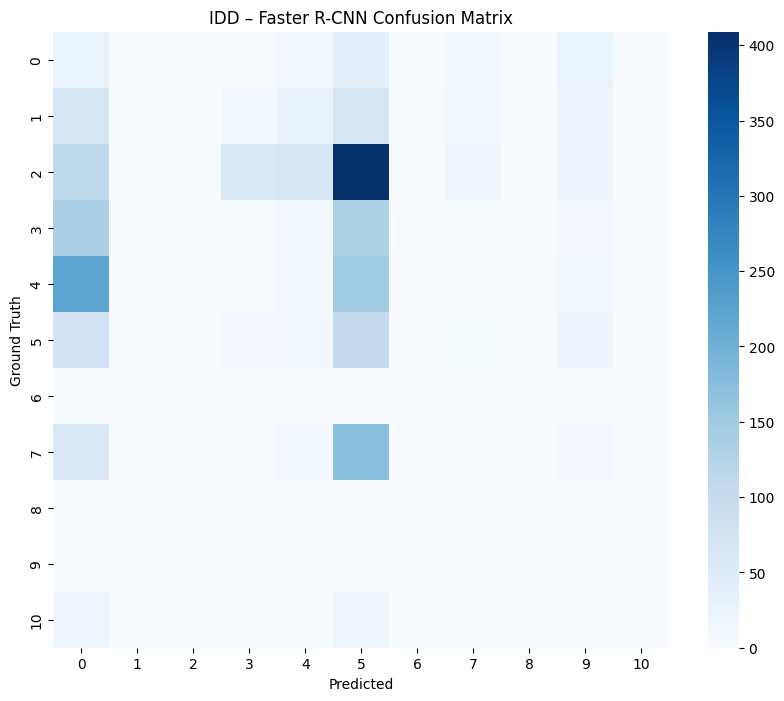

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

IOU_MATCH = 0.5

for pred, gt in zip(all_preds, all_targets):
    matched_gt = set()

    for pbox, plabel in zip(pred["boxes"], pred["labels"]):
        best_iou = 0
        best_gt = -1

        for j, (gbox, glabel) in enumerate(zip(gt["boxes"], gt["labels"])):
            if j in matched_gt:
                continue
            iou = compute_iou(pbox.numpy(), gbox.numpy())
            if iou > best_iou:
                best_iou = iou
                best_gt = j

        if best_iou >= IOU_MATCH:
            y_pred.append(int(plabel))
            y_true.append(int(gt["labels"][best_gt]))
            matched_gt.add(best_gt)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", square=True)
plt.title("IDD – Faster R-CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.show()


In [21]:
import pandas as pd

# Your table
data = [
    [4, 406, 452],
    [3, 1441, 2485],
    [1, 349, 840],
    [2, 615, 1056],
    [6, 1009, 1264],
    [0, 0, 4287],
    [5, 504, 423],
    [8, 95, 74],
    [0, 0, 1460],
    [0, 0, 569],
    [0, 0, 919],
]

df = pd.DataFrame(data, columns=["TP", "FP", "FN"])

TP = df["TP"].sum()
FP = df["FP"].sum()
FN = df["FN"].sum()

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)
fnr = FN / (TP + FN + 1e-6)
fpr = FP / (FP + TP + 1e-6)

print("✅ OVERALL RESULTS (IDD)")
print(f"Total TP: {TP}")
print(f"Total FP: {FP}")
print(f"Total FN: {FN}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"FNR       : {fnr:.4f}")
print(f"FPR       : {fpr:.4f}")


✅ OVERALL RESULTS (IDD)
Total TP: 29
Total FP: 4419
Total FN: 13829
Precision : 0.0065
Recall    : 0.0021
F1-score  : 0.0032
FNR       : 0.9979
FPR       : 0.9935


In [22]:
# ==============================================================
# Faster R-CNN Speed Benchmark (YOLO / EfficientDet Comparable)
# Resolution: 640 x 640
# Batch size: 1
# Metrics:
#   - Pure Inference Time (ms/frame)
#   - Inference FPS
#   - End-to-End Latency (ms/frame)
#   - Latency FPS
#   - Model Parameters (M)
#   - Model File Size (MB)
# ==============================================================

import torch
import cv2
import time
import csv
import os
from pathlib import Path
import torchvision
from torchvision.transforms import functional as F

# -----------------------------
# CONFIGURATION
# -----------------------------
weights_path = "fasterrcnn_kitti.pth"   # your trained Faster R-CNN checkpoint
img_path = "/workspace/0000240.jpg"
img_size = 640
batch_size = 1
csv_file = "benchmark_results_fasterrcnn_idd.csv"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------
# DEVICE INFO
# -----------------------------
print(f"\nUsing device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}\n")

# -----------------------------
# LOAD MODEL
# -----------------------------
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

# load trained weights
ckpt = torch.load(weights_path, map_location=device)
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model.to(device)
model.eval()

# -----------------------------
# MODEL STATS
# -----------------------------
model_name = Path(weights_path).stem
model_size_mb = Path(weights_path).stat().st_size / (1024 ** 2)
params_count = sum(p.numel() for p in model.parameters())
params_million = params_count / 1e6

print(f"Model: {model_name}")
print(f"Parameters: {params_million:.2f} M")
print(f"Model file size: {model_size_mb:.2f} MB\n")

# ==============================================================
# 1️⃣ PURE INFERENCE SPEED (FORWARD PASS ONLY)
# ==============================================================

dummy_input = torch.randn(
    batch_size, 3, img_size, img_size, device=device
)

# Warm-up
for _ in range(10):
    with torch.no_grad():
        model(dummy_input)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

n_runs = 100

starter.record()
with torch.no_grad():
    for _ in range(n_runs):
        model(dummy_input)
ender.record()

torch.cuda.synchronize()

inference_time_ms = starter.elapsed_time(ender) / n_runs
inference_fps = 1000 / inference_time_ms

print("=== Pure Inference (Forward Pass Only) ===")
print(f"Inference Time:  {inference_time_ms:.2f} ms/frame")
print(f"Inference Speed: {inference_fps:.2f} FPS @ {img_size}x{img_size}\n")

# ==============================================================
# 2️⃣ END-TO-END LATENCY (PRE + INFER + POST)
# ==============================================================

img = cv2.imread(img_path)
assert img is not None, "Failed to load image."

def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return img.unsqueeze(0).to(device)

# Warm-up
for _ in range(5):
    x = preprocess(img)
    with torch.no_grad():
        _ = model(x)

torch.cuda.synchronize()

starter.record()
for _ in range(30):
    x = preprocess(img)
    with torch.no_grad():
        _ = model(x)
ender.record()

torch.cuda.synchronize()

latency_ms = starter.elapsed_time(ender) / 30
latency_fps = 1000 / latency_ms

print("=== End-to-End Latency (Full Pipeline) ===")
print(f"Latency:     {latency_ms:.2f} ms/frame")
print(f"Latency FPS:{latency_fps:.2f}\n")

# ==============================================================
# 3️⃣ SAVE RESULTS TO CSV
# ==============================================================

fieldnames = [
    "Model", "GPU", "Batch_Size", "Image_Size",
    "Params_(M)", "Model_Size_(MB)",
    "Inference_Time_(ms)", "Inference_FPS",
    "Latency_(ms)", "Latency_FPS"
]

file_exists = os.path.isfile(csv_file)

with open(csv_file, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    writer.writerow({
        "Model": model_name,
        "GPU": torch.cuda.get_device_name(0),
        "Batch_Size": batch_size,
        "Image_Size": f"{img_size}x{img_size}",
        "Params_(M)": round(params_million, 2),
        "Model_Size_(MB)": round(model_size_mb, 2),
        "Inference_Time_(ms)": round(inference_time_ms, 2),
        "Inference_FPS": round(inference_fps, 2),
        "Latency_(ms)": round(latency_ms, 2),
        "Latency_FPS": round(latency_fps, 2),
    })

print(f"Benchmark results saved to: {csv_file}")

# ==============================================================
# SUMMARY
# ==============================================================
print("\n=== Benchmark Summary ===")
print(f"Model:            {model_name}")
print(f"GPU:              {torch.cuda.get_device_name(0)}")
print(f"Input Resolution: {img_size}x{img_size}")
print(f"Batch Size:       {batch_size}")
print(f"Parameters:       {params_million:.2f} M")
print(f"Model Size:       {model_size_mb:.2f} MB")
print(f"Inference Time:   {inference_time_ms:.2f} ms ({inference_fps:.2f} FPS)")
print(f"Latency:          {latency_ms:.2f} ms ({latency_fps:.2f} FPS)")
print("=============================================================")



Using device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
CUDA Version: 12.6
cuDNN Version: 90600



/tmp/ipykernel_302310/1542484956.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weights_path, map_location=device)


RuntimeError: Error(s) in loading state_dict for FasterRCNN:
	size mismatch for roi_heads.box_predictor.cls_score.weight: copying a param with shape torch.Size([12, 1024]) from checkpoint, the shape in current model is torch.Size([91, 1024]).
	size mismatch for roi_heads.box_predictor.cls_score.bias: copying a param with shape torch.Size([12]) from checkpoint, the shape in current model is torch.Size([91]).
	size mismatch for roi_heads.box_predictor.bbox_pred.weight: copying a param with shape torch.Size([48, 1024]) from checkpoint, the shape in current model is torch.Size([364, 1024]).
	size mismatch for roi_heads.box_predictor.bbox_pred.bias: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([364]).

In [27]:
import torch
import time
import os
from pathlib import Path
import csv
import cv2
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


In [28]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"\nUsing device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}\n")



Using device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
CUDA Version: 12.6
cuDNN Version: 90600



In [32]:
# -----------------------------
# CONFIG
# -----------------------------
weights_path = "fasterrcnn_kitti.pth"   # your trained checkpoint
img_path = "/workspace/0000240.jpg"   # any validation image
batch_size = 1
img_size = (800, 1333)                # Faster R-CNN default
csv_file = "benchmark_results_fasterrcnn_idd.csv"

NUM_CLASSES = 12  # IMPORTANT: background + IDD classes


In [33]:
# Base model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

# Replace classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)


In [34]:
ckpt = torch.load(weights_path, map_location=device)

if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
else:
    model.load_state_dict(ckpt, strict=True)

model.to(device)
model.eval()


/tmp/ipykernel_302310/1914707979.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weights_path, map_location=device)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [35]:
params = sum(p.numel() for p in model.parameters())
params_million = params / 1e6
model_size_mb = Path(weights_path).stat().st_size / (1024 ** 2)

print("Model: Faster R-CNN (ResNet50-FPN)")
print(f"Parameters: {params_million:.2f} M")
print(f"Model file size: {model_size_mb:.2f} MB\n")


Model: Faster R-CNN (ResNet50-FPN)
Parameters: 41.35 M
Model file size: 158.25 MB



In [36]:
dummy_input = torch.randn(
    batch_size, 3, img_size[0], img_size[1], device=device
)

# Warm-up
for _ in range(10):
    _ = model(dummy_input)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

n_runs = 100

starter.record()
with torch.inference_mode():
    for _ in range(n_runs):
        _ = model(dummy_input)
ender.record()

torch.cuda.synchronize()

inference_time_ms = starter.elapsed_time(ender) / n_runs
inference_fps = 1000 / inference_time_ms

print("=== Pure Inference (Forward Pass Only) ===")
print(f"Inference Time:  {inference_time_ms:.2f} ms/frame")
print(f"Inference Speed: {inference_fps:.2f} FPS\n")


=== Pure Inference (Forward Pass Only) ===
Inference Time:  17.16 ms/frame
Inference Speed: 58.29 FPS



In [37]:
img = cv2.imread(img_path)
assert img is not None, "Image not found!"

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0

# Warm-up
for _ in range(5):
    _ = model(img_tensor)

torch.cuda.synchronize()

starter.record()
for _ in range(30):
    _ = model(img_tensor)
ender.record()

torch.cuda.synchronize()

latency_ms = starter.elapsed_time(ender) / 30
latency_fps = 1000 / latency_ms

print("=== End-to-End Latency ===")
print(f"Latency:     {latency_ms:.2f} ms/frame")
print(f"Latency FPS:{latency_fps:.2f}\n")


=== End-to-End Latency ===
Latency:     17.28 ms/frame
Latency FPS:57.88



In [38]:
fieldnames = [
    "Model",
    "GPU",
    "Batch_Size",
    "Image_Size",
    "Params_(M)",
    "Model_Size_(MB)",
    "Inference_Time_(ms)",
    "Inference_FPS",
    "Latency_(ms)",
    "Latency_FPS",
]

file_exists = os.path.isfile(csv_file)

with open(csv_file, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    writer.writerow({
        "Model": "Faster R-CNN ResNet50-FPN (IDD)",
        "GPU": torch.cuda.get_device_name(0),
        "Batch_Size": batch_size,
        "Image_Size": "800x1333",
        "Params_(M)": round(params_million, 2),
        "Model_Size_(MB)": round(model_size_mb, 2),
        "Inference_Time_(ms)": round(inference_time_ms, 2),
        "Inference_FPS": round(inference_fps, 2),
        "Latency_(ms)": round(latency_ms, 2),
        "Latency_FPS": round(latency_fps, 2),
    })

print(f"Benchmark results saved to: {csv_file}")


Benchmark results saved to: benchmark_results_fasterrcnn_idd.csv


In [39]:
print("\n=== Benchmark Summary ===")
print("Model: Faster R-CNN ResNet50-FPN")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Input Resolution: 800x1333")
print(f"Batch Size: {batch_size}")
print(f"Parameters: {params_million:.2f} M")
print(f"Model Size: {model_size_mb:.2f} MB")
print(f"Inference Time: {inference_time_ms:.2f} ms ({inference_fps:.2f} FPS)")
print(f"Latency: {latency_ms:.2f} ms ({latency_fps:.2f} FPS)")
print("=" * 60)



=== Benchmark Summary ===
Model: Faster R-CNN ResNet50-FPN
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
Input Resolution: 800x1333
Batch Size: 1
Parameters: 41.35 M
Model Size: 158.25 MB
Inference Time: 17.16 ms (58.29 FPS)
Latency: 17.28 ms (57.88 FPS)


In [40]:
import torch
import torchvision
from torch.utils.data import DataLoader
import time
import os

#  Enable faster conv backend benchmarking
torch.backends.cudnn.benchmark = True

#  Optional: Use PyTorch 2.x compile for speedup (comment out if not using PyTorch 2.x)
# model = torch.compile(model)

#  Use AMP (mixed precision) support
from torch.cuda.amp import GradScaler

scaler = GradScaler()

#  Set training parameters optimized for your system
num_epochs = 50
train_batch_size = 30       # Can go higher if VRAM allows
val_batch_size = 30
learning_rate = 0.005
momentum = 0.9
weight_decay = 0.0005
save_path = "fasterrcnn_kitti.pth"

#  Use max CPU cores for loading, but keep a few for other ops
num_workers = 1

#  Use pin_memory for faster host-to-device transfers
train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=num_workers // 2,
    pin_memory=True
)

#  Optimizer: SGD with momentum and weight decay
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

#  LR Scheduler: Reduce LR after 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/tmp/ipykernel_302310/3286151368.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [41]:
from torch.cuda.amp import autocast
import torchvision
import torch
import time

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(f" Training on: {device}")
print(" Starting training...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        #  Mixed precision context
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        #  Scale gradients and backpropagate
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

    #  Update LR
    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    duration = time.time() - start_time
    print(f"[Epoch {epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f} | Time: {duration:.2f} sec")

    #  Save model after each epoch
    torch.save(model.state_dict(), f"fasterrcnn_epoch{epoch+1}.pth")

#  Final model save
torch.save(model.state_dict(), save_path)
print(" Training complete and model saved.")


 Training on: cuda
 Starting training...


/tmp/ipykernel_302310/2270272226.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1/50]  Loss: 4.5484 | Time: 1089.47 sec
[Epoch 2/50]  Loss: 4.4635 | Time: 1073.46 sec
[Epoch 3/50]  Loss: 4.4185 | Time: 1071.71 sec
[Epoch 4/50]  Loss: 4.3480 | Time: 1073.75 sec
[Epoch 5/50]  Loss: 4.3061 | Time: 1074.33 sec
[Epoch 6/50]  Loss: 3.9774 | Time: 1070.53 sec
[Epoch 7/50]  Loss: 3.9071 | Time: 1069.95 sec
[Epoch 8/50]  Loss: 3.8688 | Time: 1069.63 sec
[Epoch 9/50]  Loss: 3.8445 | Time: 1070.59 sec
[Epoch 10/50]  Loss: 3.8150 | Time: 1069.15 sec
[Epoch 11/50]  Loss: 3.7545 | Time: 1068.71 sec
[Epoch 12/50]  Loss: 3.7420 | Time: 1069.80 sec
[Epoch 13/50]  Loss: 3.7354 | Time: 1069.51 sec
[Epoch 14/50]  Loss: 3.7289 | Time: 1069.18 sec
[Epoch 15/50]  Loss: 3.7283 | Time: 1069.02 sec
[Epoch 16/50]  Loss: 3.7201 | Time: 1068.06 sec
[Epoch 17/50]  Loss: 3.7249 | Time: 1069.74 sec
[Epoch 18/50]  Loss: 3.7207 | Time: 1069.76 sec
[Epoch 19/50]  Loss: 3.7235 | Time: 1068.99 sec
[Epoch 20/50]  Loss: 3.7181 | Time: 1070.14 sec
[Epoch 21/50]  Loss: 3.7204 | Time: 1068.20 sec
[

In [42]:
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

# Switch to eval mode
model.eval()

# Store predictions and targets
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = list(img.to(device) for img in images)
        outputs = model(images)
        
        for i in range(len(outputs)):
            preds = outputs[i]
            gts = targets[i]
            
            all_preds.append({
                'boxes': preds['boxes'].cpu(),
                'labels': preds['labels'].cpu(),
                'scores': preds['scores'].cpu()
            })
            all_targets.append({
                'boxes': gts['boxes'].cpu(),
                'labels': gts['labels'].cpu()
            })



00%|██████████| 340/340 [10:08<00:00,  1.79s/it]

In [44]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import numpy as np

def compute_iou(box1, box2):
    """Compute IoU between two boxes"""
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    box1Area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2Area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return interArea / float(box1Area + box2Area - interArea)


In [45]:
from collections import defaultdict

IOU_THRESHOLD = 0.5
class_stats = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0, 'conf': [], 'gt_count': 0})

for pred, target in zip(all_preds, all_targets):
    pred_boxes = pred['boxes']
    pred_labels = pred['labels']
    pred_scores = pred['scores']
    
    gt_boxes = target['boxes']
    gt_labels = target['labels']
    
    matched_gt = set()
    
    for i, p_box in enumerate(pred_boxes):
        iou_max = 0
        match_idx = -1
        for j, g_box in enumerate(gt_boxes):
            iou = compute_iou(p_box.numpy(), g_box.numpy())
            if iou > iou_max:
                iou_max = iou
                match_idx = j

        pred_cls = int(pred_labels[i])
        
        if iou_max >= IOU_THRESHOLD and match_idx not in matched_gt and pred_cls == int(gt_labels[match_idx]):
            class_stats[pred_cls]['TP'] += 1
            class_stats[pred_cls]['conf'].append(float(pred_scores[i]))
            matched_gt.add(match_idx)
        else:
            class_stats[pred_cls]['FP'] += 1
            class_stats[pred_cls]['conf'].append(float(pred_scores[i]))
    
    for j, gt_cls in enumerate(gt_labels):
        if j not in matched_gt:
            class_stats[int(gt_cls)]['FN'] += 1
            class_stats[int(gt_cls)]['gt_count'] += 1


In [46]:
per_class_metrics = {}

for cls, stats in class_stats.items():
    TP = stats['TP']
    FP = stats['FP']
    FN = stats['FN']
    total = TP + FP + FN
    
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    fnr = FN / (TP + FN + 1e-6)
    fpr = FP / (FP + TP + 1e-6)

    per_class_metrics[cls] = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'FNR': fnr,
        'FPR': fpr,
        'TP': TP, 'FP': FP, 'FN': FN
    }

# Display the metrics
import pandas as pd
pd.DataFrame(per_class_metrics).T


,Precision,Recall,F1,FNR,FPR,TP,FP,FN
4,0.035753,0.172648,0.059238,0.827352,0.964247,1222.0,32957.0,5856.0
8,0.033040,0.162169,0.054896,0.837831,0.966960,1262.0,36934.0,6520.0
3,0.035440,0.192730,0.059870,0.807270,0.964560,4788.0,130315.0,20055.0
2,0.027752,0.134636,0.046018,0.865364,0.972248,3301.0,115645.0,21217.0
11,0.026293,0.014462,0.018660,0.985538,0.973707,62.0,2296.0,4225.0
5,0.085178,0.215216,0.122051,0.784784,0.914822,1058.0,11363.0,3858.0
6,0.037174,0.134450,0.058243,0.865550,0.962826,3427.0,88762.0,22062.0
1,0.028191,0.120810,0.045714,0.879190,0.971809,2184.0,75287.0,15894.0
9,0.062914,0.026027,0.036821,0.973973,0.937086,38.0,566.0,1422.0
7,0.004264,0.003515,0.003853,0.996485,0.995736,2.0,467.0,567.0


In [49]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)

TP_total, FP_total, FN_total = 0, 0, 0
map_list = []

for iou_thr in iou_thresholds:
    TP = FP = FN = 0

    for pred, gt in zip(all_preds, all_targets):
        matched_gt = set()

        for pbox, plabel in zip(pred["boxes"], pred["labels"]):
            best_iou = 0
            best_gt = -1

            for j, (gbox, glabel) in enumerate(zip(gt["boxes"], gt["labels"])):
                if glabel != plabel or j in matched_gt:
                    continue
                iou = compute_iou(pbox.numpy(), gbox.numpy())
                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= iou_thr:
                TP += 1
                matched_gt.add(best_gt)
            else:
                FP += 1

        FN += len(gt["boxes"]) - len(matched_gt)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    map_list.append(f1)

    if iou_thr == 0.5:
        TP_total, FP_total, FN_total = TP, FP, FN

# Final metrics
precision = TP_total / (TP_total + FP_total + 1e-6)
recall = TP_total / (TP_total + FN_total + 1e-6)

print("\n✅ OVERALL RESULTS (IDD)")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"mAP@0.5       : {map_list[0]:.4f}")
print(f"mAP@0.5:0.95  : {np.mean(map_list):.4f}")



✅ OVERALL RESULTS (IDD)
Precision     : 0.0345
Recall        : 0.1471
mAP@0.5       : 0.0559
mAP@0.5:0.95  : 0.0206


In [51]:
def compute_map(preds, targets, iou_thresholds=np.arange(0.5,1.0,0.05), score_thresh=0.5):
    aps = []

    for iou_t in iou_thresholds:
        cls_ap = []

        for cls in set(int(l) for t in targets for l in t["labels"]):
            TP = FP = FN = 0

            for pred, gt in zip(preds, targets):

                pb, pl, ps = pred["boxes"], pred["labels"], pred["scores"]
                gb, gl = gt["boxes"], gt["labels"]

                keep = ps >= score_thresh
                pb, pl, ps = pb[keep], pl[keep], ps[keep]

                order = torch.argsort(ps, descending=True)
                pb, pl = pb[order], pl[order]

                p_idx = (pl == cls).nonzero(as_tuple=True)[0]
                g_idx = (gl == cls).nonzero(as_tuple=True)[0]

                matched = set()

                for i in p_idx:
                    best_iou, best_j = 0, -1
                    for j in g_idx:
                        if j.item() in matched:
                            continue
                        iou = compute_iou(pb[i].numpy(), gb[j].numpy())
                        if iou > best_iou:
                            best_iou, best_j = iou, j.item()

                    if best_iou >= iou_t:
                        TP += 1
                        matched.add(best_j)
                    else:
                        FP += 1

                FN += max(0, len(g_idx) - len(matched))

            P = TP / (TP + FP + 1e-6)
            R = TP / (TP + FN + 1e-6)
            cls_ap.append(P)

        aps.append(np.mean(cls_ap))

    return aps


In [52]:
iou_thresholds = np.arange(0.5,1.0,0.05)
map_vals = compute_map(all_preds, all_targets, iou_thresholds)

for iou, ap in zip(iou_thresholds, map_vals):
    print(f"mAP@{iou:.2f}: {ap:.4f}")

print("\nFinal mAP@0.5:", round(map_vals[0],4))
print("Final mAP@0.5:0.95:", round(np.mean(map_vals),4))


mAP@0.50: 0.2747
mAP@0.55: 0.2447
mAP@0.60: 0.2119
mAP@0.65: 0.1740
mAP@0.70: 0.1311
mAP@0.75: 0.0866
mAP@0.80: 0.0540
mAP@0.85: 0.0250
mAP@0.90: 0.0073
mAP@0.95: 0.0006

Final mAP@0.5: 0.2747
Final mAP@0.5:0.95: 0.121


In [53]:
rows = []

for cls, s in class_stats.items():
    TP, FP, FN = s["TP"], s["FP"], s["FN"]

    P = TP / (TP + FP + 1e-6)
    R = TP / (TP + FN + 1e-6)
    F1 = 2 * P * R / (P + R + 1e-6)
    FNR = FN / (TP + FN + 1e-6)
    FPR = FP / (TP + FP + 1e-6)

    rows.append({
        "Class": cls,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "Precision": round(P,4),
        "Recall": round(R,4),
        "F1": round(F1,4),
        "FNR": round(FNR,4),
        "FPR": round(FPR,4)
    })

df_metrics = pd.DataFrame(rows)
df_metrics


,Class,TP,FP,FN,Precision,Recall,F1,FNR,FPR
0,4,1222,32957,5856,0.0358,0.1726,0.0592,0.8274,0.9642
1,8,1262,36934,6520,0.0330,0.1622,0.0549,0.8378,0.9670
2,3,4788,130315,20055,0.0354,0.1927,0.0599,0.8073,0.9646
3,2,3301,115645,21217,0.0278,0.1346,0.0460,0.8654,0.9722
4,11,62,2296,4225,0.0263,0.0145,0.0187,0.9855,0.9737
5,5,1058,11363,3858,0.0852,0.2152,0.1221,0.7848,0.9148
6,6,3427,88762,22062,0.0372,0.1345,0.0582,0.8655,0.9628
7,1,2184,75287,15894,0.0282,0.1208,0.0457,0.8792,0.9718
8,9,38,566,1422,0.0629,0.0260,0.0368,0.9740,0.9371
9,7,2,467,567,0.0043,0.0035,0.0039,0.9965,0.9957


In [54]:
def calculate_map(preds, targets, iou_thresholds=np.arange(0.5, 1.0, 0.05)):
    aps = []

    for iou_t in iou_thresholds:
        cls_ap = []

        for cls in class_stats.keys():
            TP = FP = FN = 0

            for pred, gt in zip(preds, targets):
                p_boxes = pred["boxes"]
                p_labels = pred["labels"]
                g_boxes = gt["boxes"]
                g_labels = gt["labels"]

                matched = set()

                for i in range(len(p_boxes)):
                    if int(p_labels[i]) != cls:
                        continue

                    best_iou = 0
                    best_j = -1
                    for j in range(len(g_boxes)):
                        if j in matched or int(g_labels[j]) != cls:
                            continue
                        iou = compute_iou(p_boxes[i].numpy(), g_boxes[j].numpy())
                        if iou > best_iou:
                            best_iou = iou
                            best_j = j

                    if best_iou >= iou_t:
                        TP += 1
                        matched.add(best_j)
                    else:
                        FP += 1

                FN += sum(int(l)==cls for l in g_labels) - len(matched)

            P = TP / (TP + FP + 1e-6)
            R = TP / (TP + FN + 1e-6)
            cls_ap.append(2 * P * R / (P + R + 1e-6))

        aps.append(np.mean(cls_ap))

    return aps

iou_vals = np.arange(0.5, 1.0, 0.05)
map_list = calculate_map(all_preds, all_targets, iou_vals)

print(f"Final mAP@0.5: {map_list[0]:.4f}")
print(f"Final mAP@0.5:0.95: {np.mean(map_list):.4f}")


Final mAP@0.5: 0.0464
Final mAP@0.5:0.95: 0.0175


In [55]:
df_metrics.to_csv("fasterrcnn_idd_final_metrics.csv", index=False)
print("Saved: fasterrcnn_idd_final_metrics.csv")


Saved: fasterrcnn_idd_final_metrics.csv
